## ARIMA model Exercise

[Hyndman and Athanasopoulos (2013)](https://www.otexts.org/fpp/) outline the general approach for fitting an ARIMA model to a set of time series data.

1. Plot the data. Identify any unusual observations.  

2. If necessary, transform the data (e.g. [log transformations](https://en.wikipedia.org/wiki/Data_transformation_(statistics)), [power transformations](https://en.wikipedia.org/wiki/Power_transform), etc.) to stabilize the variance.  

3. If the data is non-stationary: take first differences of the data until the data are stationary.  

4. Examine the Autocorrelation (ACF)/Partial Autocorrelation (PACF): Which AR($p$), MA($q$), ARMA($p, q$) or ARIMA($p, d, q$) model is appropriate?  

5. Choose a model and then use the [Akaike information criterion $(AICc)$](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) as a criterion to search for a better model. 

6.  Check the residuals from the chosen model by plotting the ACF of the residuals, and doing a [*Portmanteau test*](https://en.wikipedia.org/wiki/Portmanteau_test) of the residuals. If they do not look like white noise, try a modified model.  

7. Once the residuals look like white noise, calculate forecasts.  



In [ ]:
%load_ext lab_black

In [35]:
# Importing necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


## 1. Plot the data. Identify any unusual observations.  

As an example, we will fit an ARIMA model to the *global annual temperature anomalies* (`t_global`) provided by the [Berkeley Earth Surface Temperature Study](http://berkeleyearth.org/summary-of-findings/). Temperatures are given in Celsius and are reported as anomalies relative to the average of the period from January 1850 to December 2000.



In [36]:
# Load the global temperature anomaly data
t_global = pd.read_json(
    "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/t_global.json"
)
t_global["Date"] = pd.to_datetime(t_global["Date"], format="%Y-%m-%d", errors="coerce")
t_global = t_global.set_index("Date")["Monthly Anomaly_global"]

t_global

Date
1750-01-01   -0.993
1750-02-01   -1.679
1750-03-01   -0.192
1750-04-01   -0.531
1750-05-01   -1.881
              ...  
2022-05-01    1.023
2022-06-01    1.315
2022-07-01    1.289
2022-08-01    1.231
2022-09-01    1.090
Name: Monthly Anomaly_global, Length: 3273, dtype: float64

We see that the data set consist of monthly mean temperatures.

> Exercise: Aggregate the data (`t_global`) to annual mean temperatures using the `groupby()` function.


In [37]:
## Your code here ...

In [38]:
# Resample the data to annual frequency and calculate the mean for each year
temp_global_year = t_global.groupby(t_global.index.to_period("Y")).agg("mean")

Then, we need to split the data set into two parts. One part, the *training set*, is the period from 1850 to 2000. We can then learn the model parameters based on the data in the *training set*. The other part, the *test set*, is taken as the period from 2001 to 2021. This part will be used to validate our model, as we compare the model forecast with the observations. 

> Exercise: Subset the time series (`temp_global_year`) to the period 1850 to 2000 and to the period 2001 to 2016.



In [39]:
## Your code here...

In [40]:
# Split the data into training and test sets
temp_global_training = temp_global_year["1850-01-01":"2000-01-01"]
temp_global_test = temp_global_year["2000-01-01":]



Let us plot both the data sets and identify any unusual observations.


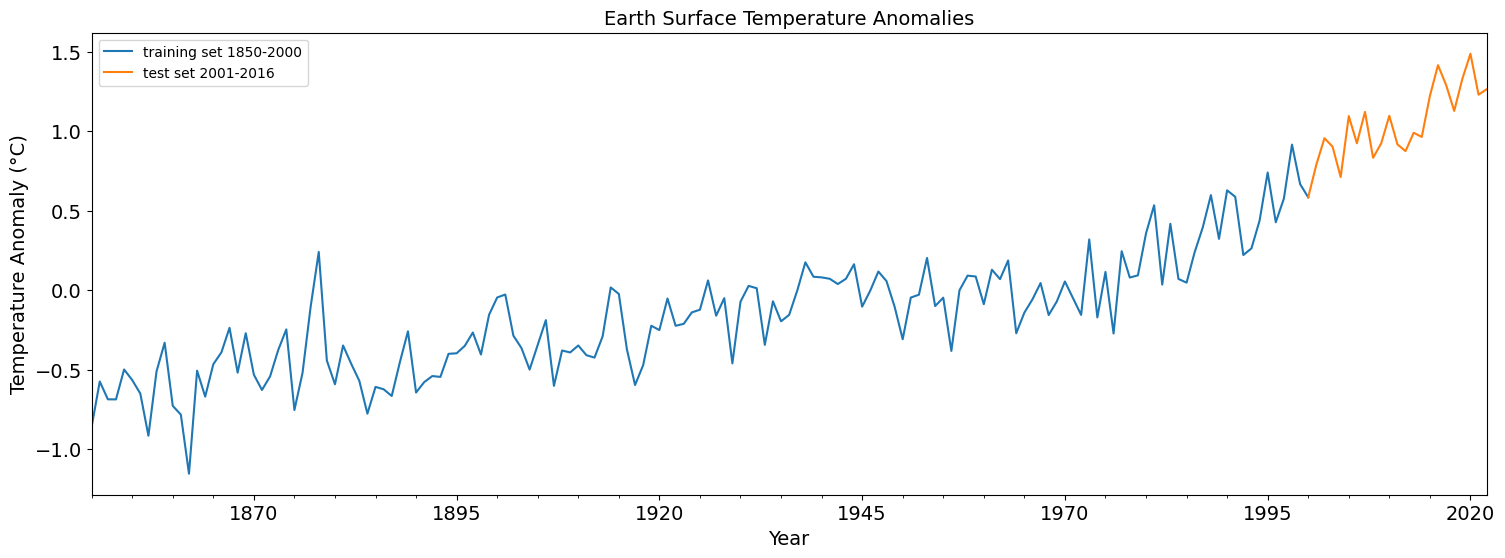

In [41]:
# Plot the training and test sets
plt.figure(figsize=(18, 6))
plt.title("Earth Surface Temperature Anomalies", fontsize=14)
temp_global_training.plot(label="training set 1850-2000", fontsize=14)
temp_global_test.plot(label="test set 2001-2016", fontsize=14)

plt.legend()
plt.xlabel("Year", fontsize=14)
plt.ylabel("Temperature Anomaly (°C)", fontsize=14)
plt.show()

It seems that there are no outliers or unusual observation in this data set. 


## 2. Transform the data to stabilize the variance.  

With respect to the plot above it does not seem that the variation increases or decreases throughout the time series. Thus, it is likely that no transformation is required. However, just as a sanity check we apply a [*Box-Cox transformation*](https://en.wikipedia.org/wiki/Power_transform) using the [`scipy.stats.boxcox`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html()) function in Python and plot the transformed data against the original data. 

The Box-Cox transformation is defined as follows:

$$
w_t =
\begin{cases}
log(y_t)  & \text{if } \lambda=0 \\
(y_t^{\lambda}-1)/\lambda & \text{otherwise}
\end{cases}
$$

The Box-Cox transformation depends on the parameter $\lambda$. So if $\lambda =0$ the natural logarithm is used, but if $\lambda \ne0$, a power transformation is used followed by some simple scaling. We can make use of the `scipy.stats.boxcox` function, which chooses the value of $\lambda$, that minimizes the [coefficient of variation](https://en.wikipedia.org/wiki/Coefficient_of_variation) and uses the chosen value within the transformation. 

Additionally, the Box-Cox transformation requires strictly positive values, so as some of the temperature anomalies are negative, we need to shift the series by adding a constant to make all values positive before transforming (use $+ 10$ in the example).


In [42]:
from scipy.stats import boxcox

# Apply Box-Cox transformation to the training data
boxcox_transformed_data, boxcox_lamba = boxcox(temp_global_training + 10)
boxcox_transformed_data = pd.Series(
    boxcox_transformed_data, index=temp_global_training.index
)

We use the given $\lambda$ of the `scipy.stats.boxcox` function and plot the transformed time series alongside the original time series.

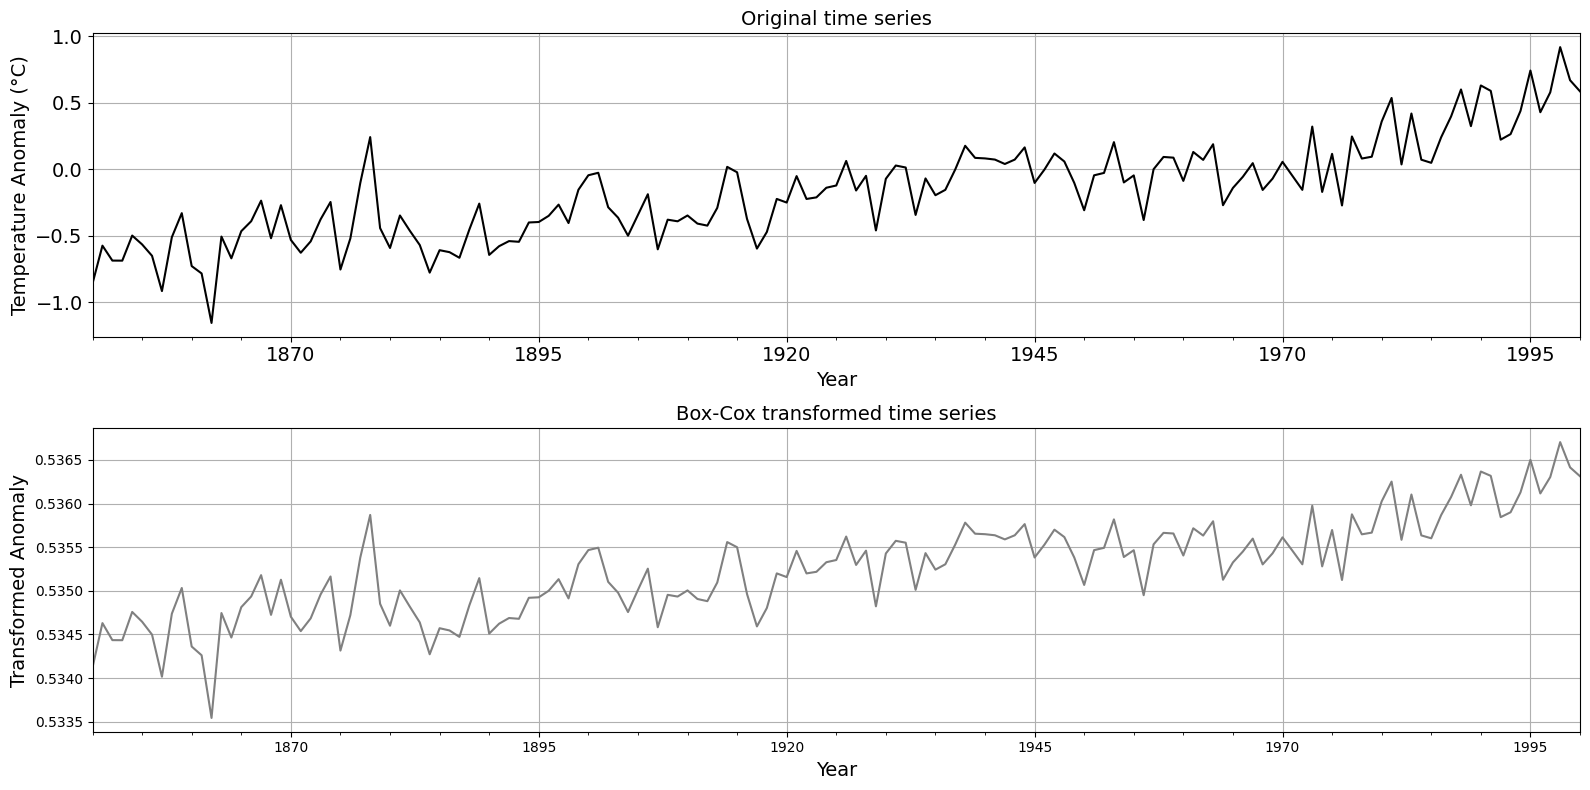

In [43]:
# Plot the original and Box-Cox transformed time series
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
temp_global_training.plot(ax=ax[0], color="black", fontsize=14)
ax[0].set_title("Original time series", fontsize=14)

boxcox_transformed_data.plot(
    ax=ax[1],
    color="grey",
)
ax[1].set_title("Box-Cox transformed time series", fontsize=14)

ax[0].grid()
ax[0].set_xlabel("Year", fontsize=14)
ax[0].set_ylabel("Temperature Anomaly (°C)", fontsize=14)
ax[1].grid()
ax[1].set_xlabel("Year", fontsize=14)
ax[1].set_ylabel("Transformed Anomaly", fontsize=14)

plt.tight_layout()
plt.show()

The Box-Cox transformed time series (gray line) does not differ significantly from the original time series (black line). Hence, we continue our analysis with the original time series data. 


## 3. Check if the data is non-stationary: take first differences of the data until the data are stationary.  

Fitting an ARMA model requires the series to be stationary, which means that the *mean*, *variance*, and *autocovariance* of the series are time invariant. Based on our domain knowledge and the visualization of the time series data it can be assumed that the temperature time series is not stationary. 

However, as a proof of concept we need to apply the [**Kwiatkowski-Phillips-Schmidt-Shin (KPSS)**](https://en.wikipedia.org/wiki/KPSS_test) test. 

Where, the null hypothesis in a KPSS test is that a time series is stationary. 

$H_0:\text{The time series is trend-stationary.}$

$H_A:\text{The time series is not trend-stationary.}$

In [44]:
from statsmodels.tsa.stattools import kpss

# Define a function to perform the KPSS test
def kpss_test(series, **kw):
    statistic, p_value, n_lags, critical_values = kpss(series, **kw)
    # Format Output
    print(f"KPSS Statistic: {statistic}")
    print(f"p-value: {p_value}")
    print(f"num lags: {n_lags}")
    print("Critial Values:")
    for key, value in critical_values.items():
        print(f"   {key} : {value}")
    print(f'Result: The series is {"not " if p_value < 0.05 else ""}stationary')

In [45]:
# Apply KPSS test to the original training data
kpss_test(temp_global_training)

KPSS Statistic: 1.613241516211716
p-value: 0.01
num lags: 8
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is not stationary


C:\Users\imk2s\AppData\Local\Temp\ipykernel_35588\226188002.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, **kw)


The *p*-value of the KPSS test on the original data set (`temp_global_training`) is $p<0.01$. Hence we reject $H_0$ in favor of $H_A$; the original time series is **not** trend-stationary.

A non-stationary series can be corrected by a simple transformation such as differencing, where the difference $(\Delta y_t)$ is calculated by subtracting one period's values from the previous period's values. Let us apply the `diff()` function and compute the KPSS test for the differenced time series.

> Exercise: Difference the `temp_global_training` time series and apply a KPSS test on the differenced time series.


In [46]:
## Your code here...

In [47]:
# Apply first-order differencing to the dataset
temp_global_training_diff1 = temp_global_training.diff()

In [48]:
# Apply KPSS test to the first-order differenced data
kpss_test(temp_global_training_diff1.dropna())  ## ignore NaN for kpss

KPSS Statistic: 0.09763391721783829
p-value: 0.1
num lags: 24
Critial Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
Result: The series is stationary


C:\Users\imk2s\AppData\Local\Temp\ipykernel_35588\226188002.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(series, **kw)



The *p*-value of the KPSS test on the differenced data set (`temp_global_training_diff1`) is $p>0.1$. Hence we do not reject $H_0$ in favor of $H_A$; the differenced time series **is** trend-stationary.

Let us plot the stationary differenced data set.

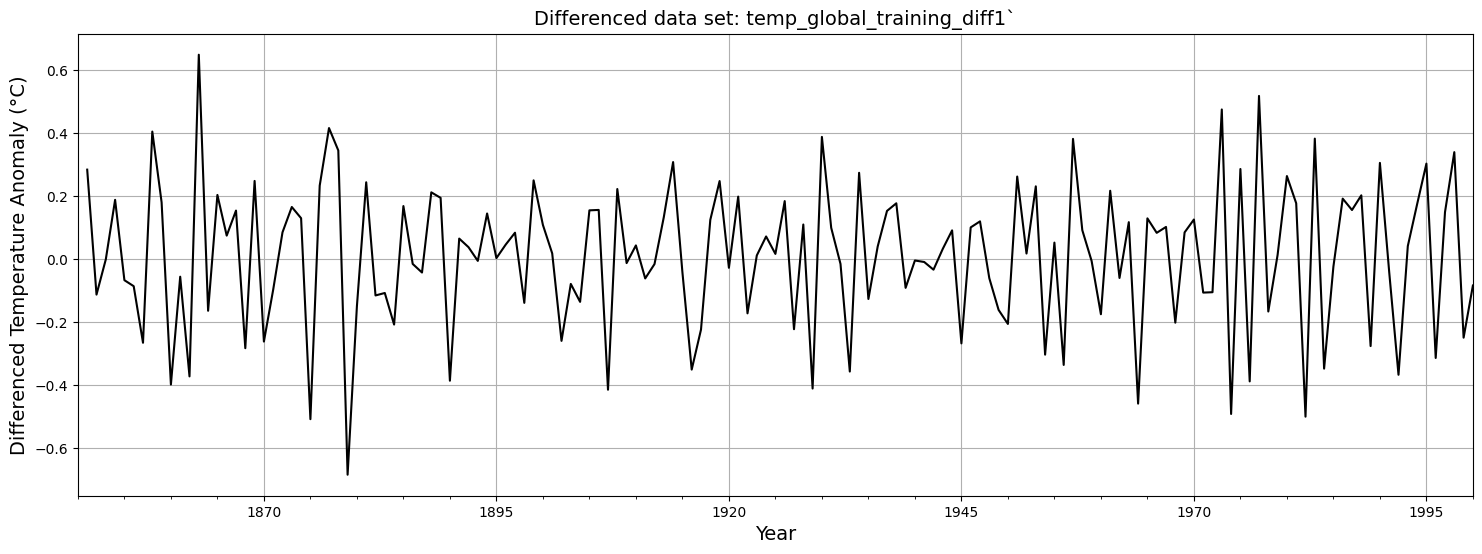

In [49]:
# Plot the differenced data
plt.figure(figsize=(18, 6))
plt.title("Differenced data set: temp_global_training_diff1`", fontsize=14)
temp_global_training_diff1.plot(color="black")

plt.grid()
plt.xlabel("Year", fontsize=14)
plt.ylabel("Differenced Temperature Anomaly (°C)", fontsize=14)
plt.show()

## 4. Examine the ACF/PACF: Which AR($p$), MA($q$), ARMA($p, q$) or ARIMA($p, d, q$) model is appropriate?  

In the next step, we need to identify a time series model. We need to find out which AR($p$), MA($q$), ARMA($p, q$) or ARIMA($p, d, q$) model is appropriate for our data set.

We have seen that it is possible to distinguish between AR, MA and ARMA models by the behavior of their ACF and PACF functions. If the ACF exhibits slow decay and the PACF cuts off sharply after lag $p$, we would identify the series as AR($p$). If the PACF shows slow decay and the ACF show a sharp cutoff after lag $q$, we would identify the series as being MA($q$). If both the ACF and PACF show slow decay we would identify the series as being mixed ARMA.

The theoretical behavior of ACF and PACF for ARMA models is summarized below ([Shumway and Stoffer 2011](http://www.springer.com/gp/book/9783319524511) and [Wei 2006](http://civil.colorado.edu/~balajir/CVEN6833/lectures/wwts-book.pdf)).

$$
\begin{array}{l|lll}
 & \text{AR}(p) & \text{MA}(q) & \text{ARMA}(p,q) \\
\hline
\text{ACF} & \text{Tails off}^\text{1} & \text{Cuts off after lag }q & \text{Tails off after lag (}q-p\text{)} \\
\text{PACF} & \text{Cuts off after lag }p &  \text{Tails off}^\text{1}  & \text{Tails off after lag (}p-q\text{)}\\
\hline
\end{array}\\
\text{${}^{1}$ Tails off can be as exponential decay or damped sine wave.}
$$

It should be noted that the sampling variation and the correlation among the sample ACF and PACF often disguise the theoretical ACF and PACF patterns. Hence, in the initial model identification it is recommendable to concentrate on the general broad features of these sample ACF and PACF. Model improvement can be easily achieved at a later stage of diagnostic checking ([Wei 2006](http://civil.colorado.edu/~balajir/CVEN6833/lectures/wwts-book.pdf)).


Let us plot the autocorrelation function and partial autocorrelation function to review the correlational structure of the differentiated time series and try to figure out the appropriate model configuration. We can use the `plot_acf()` and `plot_pacf()` functions from `statsmodels.graphics.tsaplots`.



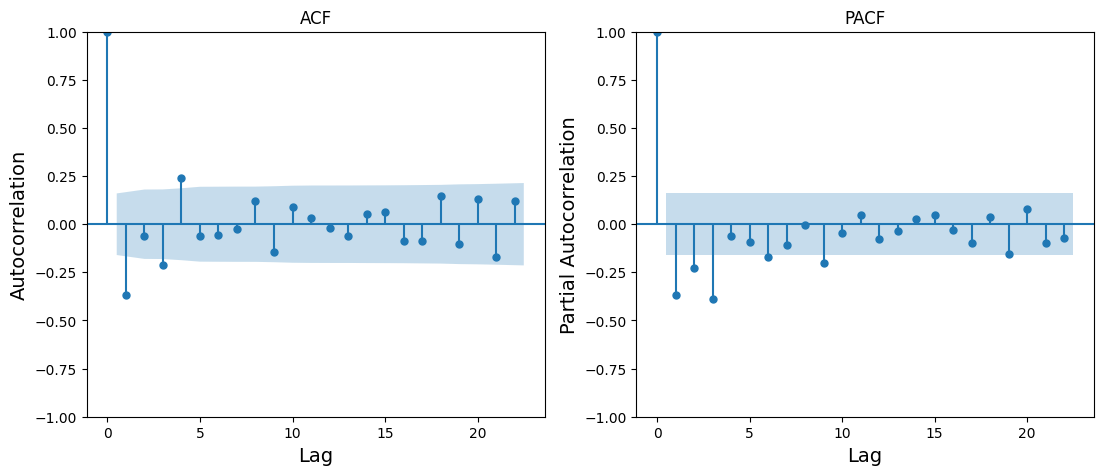

In [50]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot the ACF for the differenced series
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

plot_acf(temp_global_training_diff1.dropna(), ax=ax[0])
ax[0].set_title("ACF")
ax[0].set_xlabel("Lag", fontsize=14)
ax[0].set_ylabel("Autocorrelation", fontsize=14)

# Plot the PACF for the differenced series
plot_pacf(
    temp_global_training_diff1.dropna(), method="ywm", ax=ax[1]
)  ## add the calculation method running in the background ("ywm")

ax[1].set_title("PACF")
ax[1].set_xlabel("Lag", fontsize=14)
ax[1].set_ylabel("Partial Autocorrelation", fontsize=14)

plt.show()

The ACF plot shows significant spikes at a lag of 1, 3 and 4 years and tails off like a damped sine wave. The PACF cuts off after lag $p=3$. 

We also know that it required one single differencing in order to make the time series stationary in step 3., therefore $d=1$.

This suggests that an ARIMA(3, 1, 0) process model would be appropriate. 

## 5. Choose a model and then use the [$(AICc)$](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) as a criterion to search for a better model. 

In Python you can use the class `statsmodels.tsa.arima.model.ARIMA(endog, order, exog=None, dates=None, freq=None, missing='none')`, for time series forecasting. See the documentation of the function [here](https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima_model.ARIMA.html) for further information. 

Recall what **ARIMA** stands for: 

* **AR**: Autoregression. A model that uses the dependent relationship between an observation and some number of lagged observations.
* **I**: Integrated. The use of differencing of raw observations (e.g. subtracting an observation from an observation at the previous time step) in order to make the time series stationary.
* **MA**: Moving Average. A model that uses the dependency between an observation and a residual error from a moving average model applied to lagged observations.

The parameters of the ARIMA model:

* **p**: The number of lag observations included in the model, also called the lag order.
* **d**: The number of times that the raw observations are differenced, also called the degree of differencing.
* **q**: The size of the moving average window, also called the order of moving average.


In [51]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the chosen model
model = ARIMA(temp_global_training, order=(3, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                                 SARIMAX Results                                  
Dep. Variable:     Monthly Anomaly_global   No. Observations:                  151
Model:                     ARIMA(3, 1, 0)   Log Likelihood                  32.139
Date:                    Tue, 10 Mar 2026   AIC                            -56.278
Time:                            17:04:45   BIC                            -44.235
Sample:                        12-31-1850   HQIC                           -51.385
                             - 12-31-2000                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5353      0.074     -7.225      0.000      -0.681      -0.390
ar.L2         -0.3974      0.078     -5.079      0.000      -0.551      -0.244
ar.L3         -0.385

In [52]:
# Extract the ARIMA parameters:
print(
    "AR 1 =",
    round(model_fit.params["ar.L1"], 4),
    "AR 2 =",
    round(model_fit.params["ar.L2"], 4),
    "AR 3 =",
    round(model_fit.params["ar.L3"], 4),
    "sigma =",
    round(model_fit.params["sigma2"], 4),
)

aicc = model_fit.aicc
print(f"AICc: {round(aicc, 4)}")

AR 1 = -0.5353 AR 2 = -0.3974 AR 3 = -0.3856 sigma = 0.038
AICc: -56.0019


This is an ARIMA(3, 1, 0) model written as 

$\Delta y_t = -0.5353 y_{t-1}- 0.3974 y_{t-2} -0.3856 y_{t-3}+ w_t\text{,}$

where $w_t$ is white noise with a standard deviation of $\sqrt{ 0.038} = 0.195$.

The corrected version of [Akaike information criterion $(AICc)$](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) of this model is -56.00. This model quality metric is useful when comparing different models. In ARIMA modelling it is good practice to check some more models and compare them by comparing the $AICc$.

> Exercise: Fit some variations of ARIMA($p$, $d$, $q$) models including ARIMA(3, 1, 1), ARIMA(3, 1, 2), ARIMA(2, 1, 2) and compare their $AICc$.


In [53]:
## Your code here...

In [54]:
# Fit different ARIMA models and compare their AICc values
model = ARIMA(temp_global_training, order=(3, 1, 0))
model_fit = model.fit()
print(f"ARIMA(3,1,0) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(3, 1, 1))
model_fit = model.fit()
print(f"ARIMA(3,1,1) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(3, 1, 2))
model_fit = model.fit()
print(f"ARIMA(3,1,2) - AICc: {round(model_fit.aicc,2)}")

model = ARIMA(temp_global_training, order=(2, 1, 2))
model_fit = model.fit()
print(f"ARIMA(2,1,2) - AICc: {round(model_fit.aicc,2)}")

ARIMA(3,1,0) - AICc: -56.0
ARIMA(3,1,1) - AICc: -55.48
ARIMA(3,1,2) - AICc: -55.84
ARIMA(2,1,2) - AICc: -53.28


Of these, the ARIMA(3, 1, 0) has the smallest $AICc$ value. Therefore that can be considered out best model so far.

### Use a function to automatically find the optimal model

The [`pmdarima`](https://pypi.org/project/pmdarima/) (pyramid-arima) package includes the [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) function. The function uses a variation of the [*Hyndman and Khandakar algorithm*](https://robjhyndman.com/publications/automatic-forecasting/) which combines [unit root tests](https://en.wikipedia.org/wiki/Unit_root_test), minimization of the [AICc](https://en.wikipedia.org/wiki/Akaike_information_criterion#AICc) and [maximum likelihood estimation (MLE)](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation) to obtain an optimized ARIMA model. The [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) generates a set of optimal ($p$, $d$, $q$) that optimizes model fit criteria by searching through combinations of order parameters. See the documentation of the function [here](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html).


In [55]:
from pmdarima.arima import auto_arima

# Use auto_arima to find the best ARIMA model based on AICc
auto_model = auto_arima(temp_global_training)
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  151
Model:               SARIMAX(4, 1, 1)   Log Likelihood                  38.083
Date:                Tue, 10 Mar 2026   AIC                            -62.165
Time:                        17:04:50   BIC                            -41.091
Sample:                    12-31-1850   HQIC                           -53.603
                         - 12-31-2000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0040      0.002      1.671      0.095      -0.001       0.009
ar.L1          0.3102      0.102      3.037      0.002       0.110       0.510
ar.L2          0.0441      0.090      0.489      0.625      -0.133       0.221
ar.L3         -0.1101      0.082     -1.339      0.180      -0.271       0.051
ar.L4          0.2467      0.086      2.857      0.004       0.077       0.416
ma.L1         -0.9560      0.059    -16.248      0.000      -1.071      -0.841
sigma2         0.0342      0.004      8.030      0.000       0.026       0.043
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.48
Prob(Q):                              0.95   Prob(JB):                         0.79
Heteroskedasticity (H):               0.99   Skew:                             0.02
Prob(H) (two-sided):                  0.97   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The [`auto.arima()`](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html) function returns an ARIMA(4, 1, 1) process, with an $AICc$ of -62.165. This metric is lower compared to our best model so far. Therefore the optimum model with the lowest AICc is ARIMA(4, 1, 1).

## 6.  Check the residuals from the chosen model by plotting the ACF of the residuals, and doing a [*Portmanteau test*](https://en.wikipedia.org/wiki/Portmanteau_test) of the residuals. If they do not look like white noise, try a modified model.  

Now let us check the residuals from our chosen model.

> Exercise: Plot the ACF of the residuals from the `auto_model` model.


In [56]:
## Your code here...

In [57]:
# Extract the residuals from the fitted model
residuals = pd.DataFrame(auto_model.resid())

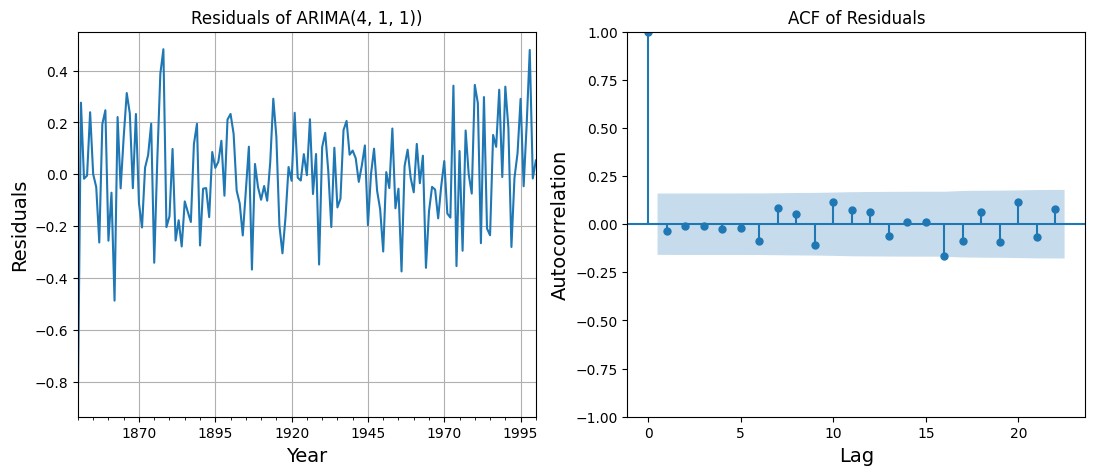

In [58]:
# Plot the residuals and their ACF
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

residuals.plot(ax=ax[0], legend=False)
ax[0].grid()
ax[0].set_title("Residuals of ARIMA(4, 1, 1))")
ax[0].set_xlabel("Year", fontsize=14)
ax[0].set_ylabel("Residuals", fontsize=14)

plot_acf(residuals, ax=ax[1])
ax[1].set_title("ACF of Residuals")
ax[1].set_xlabel("Lag", fontsize=14)
ax[1].set_ylabel("Autocorrelation", fontsize=14)

plt.show()

The ACF plot of the residuals from the ARIMA(4, 1, 1) model shows all correlations within the threshold limits (blue band) indicating that the residuals are behaving like white noise.

In addition to considering the ACF plot, where we are implicitly carrying out multiple hypothesis tests, each one with a small probability of giving a false positive, we may apply a more formal test for autocorrelation. A [*portmanteau test*](https://en.wikipedia.org/wiki/Portmanteau_test), from a French word describing a suitcase containing a number of items, tests a group of autocorrelations ([Hyndman and Athanasopoulos, 2013](https://www.otexts.org/fpp/)).

One such test is the [*Ljung-Box*](https://en.wikipedia.org/wiki/Ljung%E2%80%93Box_test) test based on the statistic 

$$Q=T(T+2)\sum_{k=1}^h(T-k)^{-1}r^2_k\text{,}$$

where $h$ is the maximum lag being considered, $T$ is number of observations, and $r_k$ is the autocorrelation for lag $k$.  If some $r_k$ values are large (positive or negative), then $Q$ will be large. If the autocorrelations did come from a white noise series, then both $Q$ would have a $\chi^2$ distribution with $(h-K)$ degrees of freedom where $K$ is the number of parameters in the model.  [Hyndman and Athanasopoulos (2013)](https://www.otexts.org/fpp/) suggest using $h=10$ for non-seasonal data and $h=2m$ for seasonal data, where $m$ is the period of seasonality. See the documentation of the function in Python [here](https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).



**Ljung-Box test**

$H_0: \text{The data is independently distributed.}$

$H_A: \text{The data is not independently distributed, it exhibits serial correlation.}$


In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test on residuals with lag=10
Btest = acorr_ljungbox(
    auto_model.resid(), lags=[10], return_df=True, model_df=5
)  ## ARIMA model_df = lags - df , df =  p +q

# Print the results
Btest

,lb_stat,lb_pvalue
10,7.324034,0.197635


The Ljung-Box test returns a large p-value (P = 0.197635), indicating no significant autocorrelation in the residual and suggests that they behave like white noise.

## 7. Calculate forecasts

Forecasting using a fitted model is straightforward in Python. We use the [`forecast()`](https://www.statsmodels.org/v0.11.1/generated/statsmodels.tsa.arima_model.ARMAResults.forecast.html) function from the [`statsmodels`](https://www.statsmodels.org/stable/index.html) package. We specify forecast horizon in `steps`, the number of out of sample forecasts from the end of the sample and use the fitted model to generate those predictions. In addition we specify `alpha`, for the confidence intervals for the forecasts (1 - `alpha` %).


In [60]:
# Fit the ARIMA(4, 1, 1) model
model = ARIMA(temp_global_training, order=(4, 1, 1))
fitted = model.fit()

In [61]:
# Forecast the next 40 years (2001-2040) with 95% confidence intervals
forecast_series = fitted.forecast(40, alpha=0.05)

c:\Users\imk2s\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


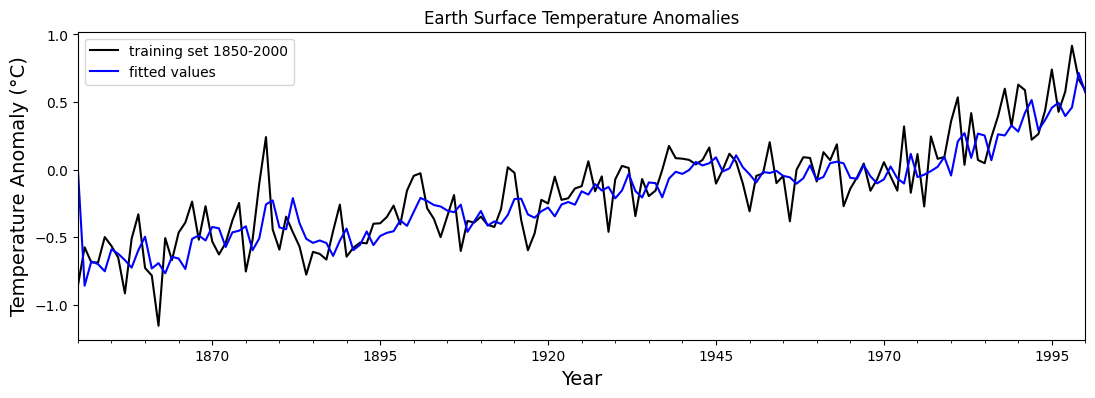

In [62]:
# Plot the original training data and the fitted values
plt.figure(figsize=(13, 4))
plt.title("Earth Surface Temperature Anomalies")
temp_global_training.plot(color="black", label="training set 1850-2000")
plt.plot(fitted.fittedvalues, color="blue", label="fitted values")

plt.legend()
plt.xlabel("Year", fontsize=14)
plt.ylabel("Temperature Anomaly (°C)", fontsize=14)
plt.show()

Now, we can see how the model compares to the original time series.

In [63]:
# Get the forecasted values and confidence intervals
forecast = fitted.get_forecast(40)
conf_int_95 = forecast.conf_int(alpha=0.05)  # 95% conf
conf_int_80 = forecast.conf_int(alpha=0.2)  # 80% conf

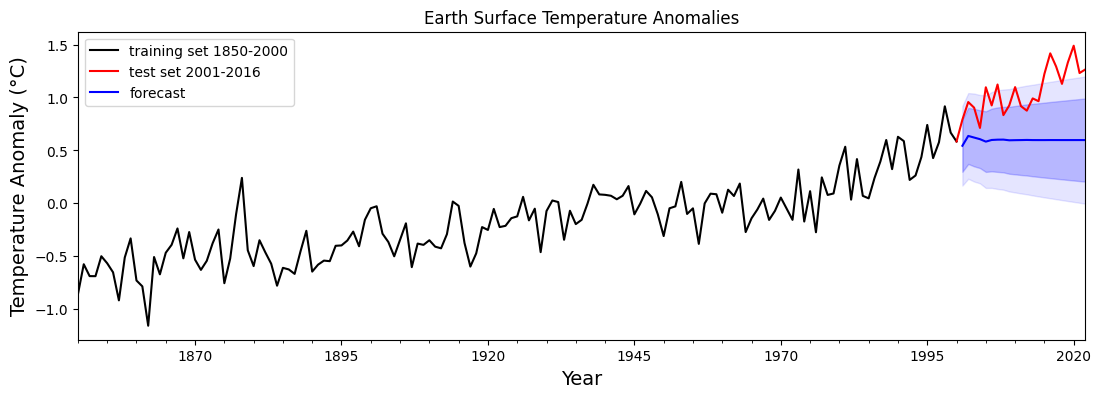

In [64]:
# Plot the original training data, the forecasted values, and the confidence intervals
plt.figure(figsize=(13, 4))
plt.title("Earth Surface Temperature Anomalies")
temp_global_training.plot(color="black", label="training set 1850-2000")
temp_global_test.plot(color="red", label="test set 2001-2016")
plt.plot(forecast_series, label="forecast", color="blue")
plt.xlabel("Year", fontsize=14)
plt.ylabel("Temperature Anomaly (°C)", fontsize=14)

plt.fill_between(
    conf_int_95.index,
    conf_int_95["lower Monthly Anomaly_global"],
    conf_int_95["upper Monthly Anomaly_global"],
    color="b",
    alpha=0.1,
)

plt.fill_between(
    conf_int_80.index,
    conf_int_80["lower Monthly Anomaly_global"],
    conf_int_80["upper Monthly Anomaly_global"],
    color="b",
    alpha=0.2,
)

plt.legend()
plt.show()


Forecast estimates are provided with confidence bounds: 80% confidence limits shaded in darker blue, and 95% in lighter blue. As you can see from the plot, the forecast does not reproduce the test data.



In [65]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))